## Multivariate Wasserstein distance evaluation

In [4]:
# imports + paths
from pathlib import Path
import pandas as pd
import numpy as np

BASE     = Path("/data/shared/fsibilla/clean_code/Q1")
EXP_BASE = BASE / "experiments"
OUT_DIR  = BASE / "across_experiments_eval"

experiments = [
    ("lka", "micron", "1"),
    ("nga", "micron", "1"),
    ("eth", "micron", "1"),
    ("lka", "vam",    "1"),
    ("moz", "vam",    "1"),
    ("yem", "mvam",   "10"),
    ("nga", "mics",   "1"),
    ("zwe", "mics",   "1"),
]

EXPERIMENT_VARS = {
    "eth_micron": ["avg_adult_education", "fe_ai",  "fol_ai",      "log_exp", "va_ai",        "vb12_ai",    "zn_ai"],
    "lka_micron": ["avg_adult_education", "fe_mg",  "folate_mcg",  "log_exp", "vita_rae_mcg", "vitb12_mcg", "zn_mg"],
    "lka_vam":    ["FCS", "FES", "education_score", "log_income", "rCSI", "space_per_person"],
    "moz_vam":    ["FCS", "FGHIron", "FGProtein", "FGVitA", "rCSI"],
    "nga_micron": ["avg_adult_education", "fe_ai",  "fol_ai",      "log_exp", "va_ai",        "vb12_ai",    "zn_ai"],
    "nga_mics":   ["avg_adult_education", "space_per_person", "wscore"],
    "yem_mvam":   ["FCS", "log_exp_pp", "rCSI"],
    "zwe_mics":   ["avg_adult_education", "space_per_person", "wscore"],
}

In [9]:
import warnings
from collections import defaultdict

RAW_RECORDS = defaultdict(dict)  # (exp_id, adm1_code, seed) -> {"gen": df, "nat": df, "true": df}

SEEDS = [5, 1, 2, 3, 4]

for country, dataset, train_int in experiments:
    exp_id = f"{country}_{dataset}"
    vars_  = EXPERIMENT_VARS[exp_id]

    for seed in SEEDS:
        n=1 if country != "yem" else 10
        pred_dir = EXP_BASE / exp_id / "results" / f"train_{n}_scaled" / f"seed_{seed}_scaled"
        if not pred_dir.exists():
            warnings.warn(f"Missing: {pred_dir}")
            continue

        for fp in sorted(pred_dir.glob("*.parquet")):
            adm1 = fp.stem  # adjust if your naming differs
            try:
                df = pd.read_parquet(fp, columns=vars_ + ["split"])
            except Exception as e:
                warnings.warn(f"Could not read {fp}: {e}")
                continue

            key = (exp_id, adm1, seed)
            RAW_RECORDS[key]["gen"]  = df[df["split"] == "gen"][vars_].dropna().to_numpy()
            RAW_RECORDS[key]["nat"]  = df[df["split"] == "nat"][vars_].dropna().to_numpy()
            RAW_RECORDS[key]["true"] = df[df["split"] == "true"][vars_].dropna().to_numpy()

print(f"Loaded {len(RAW_RECORDS)} (exp, adm1, seed) records")

Loaded 0 (exp, adm1, seed) records


In [11]:
import warnings
from collections import defaultdict

RAW_RECORDS = defaultdict(dict)  # (exp_id, adm1_code, seed) -> {"true": arr, "gen": arr, "over": arr}

SEEDS = [1, 2, 3, 4, 5]  # adjust if your seeds are 0-indexed

for country, dataset, train_int in experiments:
    exp_id = f"{country}_{dataset}"
    vars_  = EXPERIMENT_VARS[exp_id]

    for seed in SEEDS:
        seed_dir = EXP_BASE / exp_id / "results" / f"train_{train_int}_scaled" / f"seed_{seed}_scaled"

        fp_true = seed_dir / f"full_{country}_scaled_train{train_int}_seed{seed}.csv"
        fp_gen  = seed_dir / f"generated_pool_{train_int}_seed{seed}_scaled.csv"
        fp_over = seed_dir / f"train_subset_{train_int}_seed{seed}_scaled.csv"

        missing = [fp for fp in [fp_true, fp_gen, fp_over] if not fp.exists()]
        if missing:
            warnings.warn(f"[{exp_id} seed {seed}] missing: {[str(p) for p in missing]}")
            continue

        try:
            df_true = pd.read_csv(fp_true, usecols=vars_ + ["adm1name"])
            df_gen  = pd.read_csv(fp_gen,  usecols=vars_ + ["adm1name"])
            df_sub  = pd.read_csv(fp_over, usecols=vars_ + ["adm1name"])
        except Exception as e:
            warnings.warn(f"[{exp_id} seed {seed}] read error: {e}")
            continue

        # work per adm1
        for adm1 in df_true["adm1name"].dropna().unique():
            true_arr = df_true[df_true["adm1name"] == adm1][vars_].dropna().to_numpy()
            gen_arr  = df_gen[ df_gen[ "adm1name"] == adm1][vars_].dropna().to_numpy()
            sub_arr  = df_sub[ df_sub[ "adm1name"] == adm1][vars_].dropna().to_numpy()

            if true_arr.size == 0 or gen_arr.size == 0 or sub_arr.size == 0:
                continue

            # oversample train_subset to match gen size (per adm1, with replacement)
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(sub_arr), size=len(gen_arr), replace=True)
            over_arr = sub_arr[idx]

            RAW_RECORDS[(exp_id, adm1, seed)] = {
                "true": true_arr,
                "gen":  gen_arr,
                "over": over_arr,
            }

print(f"Loaded {len(RAW_RECORDS)} (exp, adm1, seed) triples")

Loaded 730 (exp, adm1, seed) triples


In [14]:
try:
    import ot
    def _wasserstein2_multivariate(X: np.ndarray, Y: np.ndarray, reg: float = 1e-2) -> float:
        n, m = len(X), len(Y)
        if n == 0 or m == 0:
            return np.nan
        mu = np.mean(np.vstack([X, Y]), axis=0)
        sd = np.std(np.vstack([X, Y]), axis=0) + 1e-8
        Xs = (X - mu) / sd
        Ys = (Y - mu) / sd
        a = np.ones(n) / n
        b = np.ones(m) / m
        M = ot.dist(Xs, Ys, metric="sqeuclidean")
        result = ot.sinkhorn2(a, b, M, reg=reg)
        # POT >= 0.9 returns a scalar, older versions return a tuple
        W2_sq = float(result[0]) if hasattr(result, "__len__") else float(result)
        return float(np.sqrt(max(W2_sq, 0.0)))
    print("Using POT (Sinkhorn W2)")

except ImportError:
    from scipy.stats import wasserstein_distance as _w1_1d
    def _wasserstein2_multivariate(X: np.ndarray, Y: np.ndarray, reg: float = None, n_proj: int = 200) -> float:
        if len(X) == 0 or len(Y) == 0:
            return np.nan
        rng = np.random.default_rng(0)
        d = X.shape[1]
        thetas = rng.standard_normal((n_proj, d))
        thetas /= np.linalg.norm(thetas, axis=1, keepdims=True)
        dists = [_w1_1d(X @ t, Y @ t) for t in thetas]
        return float(np.mean(dists))
    print("POT not found – using sliced Wasserstein fallback")

Using POT (Sinkhorn W2)


In [16]:
from tqdm.auto import tqdm
import warnings

rows = []

for (exp_id, adm1, seed), splits in tqdm(RAW_RECORDS.items()):
    gen  = splits.get("gen")
    true = splits.get("true")
    over = splits.get("over")

    if gen is None or true is None:
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        w_gen  = _wasserstein2_multivariate(gen,  true, reg=1e-1)
        w_over = _wasserstein2_multivariate(over, true, reg=1e-1) if over is not None else np.nan

    rows.append(dict(
        experiment_id=exp_id,
        adm1_code=adm1,
        seed=seed,
        w2_gen=w_gen,
        w2_over=w_over,
    ))

raw_w2 = pd.DataFrame(rows)
print(raw_w2.shape)
raw_w2.head()

100%|██████████| 730/730 [19:28<00:00,  1.60s/it]  

(730, 5)


,experiment_id,adm1_code,seed,w2_gen,w2_over
0,lka_micron,Western,1,1.796354,2.218476
1,lka_micron,Central,1,0.002954,0.002744
2,lka_micron,Southern,1,1.593861,2.537457
3,lka_micron,Northern,1,0.002478,0.002409
4,lka_micron,Eastern,1,1.557258,0.003352


In [17]:
w2_adm1 = (
    raw_w2
    .groupby(["experiment_id", "adm1_code"], as_index=False)
    .agg(
        w2_gen_mean  =("w2_gen",  "mean"),
        w2_gen_se    =("w2_gen",  lambda x: x.std(ddof=1) / np.sqrt(x.count())),
        w2_over_mean =("w2_over", "mean"),
        w2_over_se   =("w2_over", lambda x: x.std(ddof=1) / np.sqrt(x.count())),
        n_seeds      =("w2_gen",  "count"),
    )
)

w2_adm1["imp_w2_over"] = w2_adm1["w2_over_mean"] - w2_adm1["w2_gen_mean"]

print(w2_adm1.shape)
w2_adm1.head()

(146, 8)


,experiment_id,adm1_code,w2_gen_mean,w2_gen_se,w2_over_mean,w2_over_se,n_seeds,imp_w2_over
0,eth_micron,Addis Ababa,1.029024,0.418373,0.506543,0.499547,5,-0.522481
1,eth_micron,Afar,0.397470,0.384434,0.015373,0.002417,5,-0.382097
2,eth_micron,Amhara,0.777368,0.471894,0.562093,0.547894,5,-0.215276
3,eth_micron,B. Gumuz,1.168360,0.473435,0.617241,0.604286,5,-0.551119
4,eth_micron,Dire Dawa,1.723154,0.102453,0.934161,0.567834,5,-0.788993


In [19]:
import geopandas as gpd
from shapely import wkt

# reuse geom_lookup from the original notebook (or reload it)
geom_lookup = pd.read_parquet(OUT_DIR / "adm1_geometry_lookup.parquet")

g = (
    geom_lookup[["experiment_id", "adm1_code", "adm1_name", "adm1geometry"]]
    .drop_duplicates(["experiment_id", "adm1_code"])
)

w2_geo = w2_adm1.merge(g, on=["experiment_id", "adm1_code"], how="left")
w2_geo["geometry"] = w2_geo["adm1geometry"].apply(
    lambda s: wkt.loads(s) if isinstance(s, str) and s else None
)
gdf_w2 = gpd.GeoDataFrame(
    w2_geo.drop(columns=["adm1geometry"]),
    geometry="geometry",
    crs="EPSG:4326",
)
print(gdf_w2.shape)
gdf_w2.head()

(146, 10)


,experiment_id,adm1_code,w2_gen_mean,w2_gen_se,w2_over_mean,w2_over_se,n_seeds,imp_w2_over,adm1_name,geometry
0,eth_micron,Addis Ababa,1.029024,0.418373,0.506543,0.499547,5,-0.522481,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6..."
1,eth_micron,Afar,0.397470,0.384434,0.015373,0.002417,5,-0.382097,Afar,"POLYGON ((39.9832 14.4473, 39.9945 14.388, 39...."
2,eth_micron,Amhara,0.777368,0.471894,0.562093,0.547894,5,-0.215276,Amhara,"POLYGON ((36.4545 13.7674, 36.4224 13.7288, 36..."
3,eth_micron,B. Gumuz,1.168360,0.473435,0.617241,0.604286,5,-0.551119,B. Gumuz,"MULTIPOLYGON (((36.3814 9.4718, 36.3819 9.4563..."
4,eth_micron,Dire Dawa,1.723154,0.102453,0.934161,0.567834,5,-0.788993,Dire Dawa,"POLYGON ((42.3419 9.7213, 42.2968 9.7608, 42.2..."


In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          9,
    "axes.titlesize":     9,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

DISPLAY_LABELS = {
    "avg_adult_education": "Education",
    "fe_ai":        "Iron",        "fe_mg":        "Iron",
    "fol_ai":       "Folate",      "folate_mcg":   "Folate",
    "log_exp":      "Expenditures","log_exp_pp":   "Expenditures pp",
    "va_ai":        "Vitamin A",   "vita_rae_mcg": "Vitamin A",
    "vb12_ai":      "Vitamin B12", "vitb12_mcg":   "Vitamin B12",
    "zn_ai":        "Zinc",        "zn_mg":        "Zinc",
    "FCS":          "FCS",         "FES":          "FES",
    "education_score": "Education","log_income":   "Income",
    "rCSI":         "rCSI",        "space_per_person": "Space pp",
    "FGHIron":      "Iron",        "FGProtein":    "Protein",
    "FGVitA":       "Vitamin A",   "wscore":       "Wealth Score",
    "eth_micron":   "Ethiopia\nESS",   "lka_micron": "Sri Lanka\nHIES",
    "lka_vam":      "Sri Lanka\nVAM",  "moz_vam":    "Mozambique\nVAM",
    "nga_micron":   "Nigeria\nNLSS",   "nga_mics":   "Nigeria\nMICS",
    "yem_mvam":     "Yemen\nmVAM",     "zwe_mics":   "Zimbabwe\nMICS",
}

DATASET_COLORS = {
    "eth_micron": "#117733", "lka_micron": "#EE7733",
    "lka_vam":    "#4477AA", "moz_vam":    "#CC79A7",
    "nga_micron": "#88CC44", "nga_mics":   "#DDCC77",
    "yem_mvam":   "#AA7744", "zwe_mics":   "#999999",
}

cmap_rwg = LinearSegmentedColormap.from_list(
    "rwg_cb", ["#D55E00", "#FFFFFF", "#009E73"]
)

exp_ids       = sorted(gdf_w2["experiment_id"].unique().tolist())
exp_color_map = {exp: DATASET_COLORS.get(exp, "#777777") for exp in exp_ids}

In [21]:
def plot_w2_improvement(
    gdf,
    value_col,
    fig_title,
    vlim_percentile=98,
    var_fs=7,
    header_h=0.26,
    row_hspace=0.01,
    col_wspace=0.04,
    title_band=0.08,
    cb_band=0.005,
    map_w=0.75,
    row_h=1.12,
    label_col_w=0.6,
    overall_col_w=0.9,
    overall_gap=0.10,
    cb_width=0.38,
    cb_y=0.09,
):
    vals = gdf[value_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if vals.size == 0:
        print(f"No data for {value_col}")
        return

    vmax = float(np.nanpercentile(np.abs(vals), vlim_percentile))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(vals))) or 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    n_exp    = len(exp_ids)
    # W2 is a single scalar per (exp, adm1) — no per-variable breakdown
    # We show one map per experiment (overall across all vars already aggregated)
    max_cols = 1

    # Per-experiment overall average (already in value_col, one row per adm1)
    overall_by_exp = {}
    for exp_id in exp_ids:
        sub = gdf[gdf["experiment_id"] == exp_id][["geometry", value_col]].copy()
        sub = sub.dropna(subset=[value_col])
        overall_by_exp[exp_id] = sub

    box_area_w = map_w * (max_cols + label_col_w)
    overall_w  = map_w * overall_col_w
    total_w    = box_area_w + map_w * overall_gap + overall_w
    total_h    = row_h * n_exp

    fig = plt.figure(figsize=(total_w, total_h))

    root = GridSpec(
        nrows=1, ncols=2, figure=fig,
        width_ratios=[box_area_w, overall_w],
        wspace=overall_gap / (max_cols + label_col_w),
    )
    left_gs = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 0],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )
    right_gs = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 1],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )

    # title
    ax_t = fig.add_subplot(left_gs[0, 0])
    ax_t.axis("off")
    ax_t.text(0.5, 0.55, str(fig_title),
              ha="center", va="center", fontsize=9, fontweight="bold",
              transform=ax_t.transAxes)

    ax_overall_title = fig.add_subplot(right_gs[0, 0])
    ax_overall_title.axis("off")
    ax_overall_title.text(0.5, 0.55, "All regions",
                          ha="center", va="center", fontsize=9,
                          transform=ax_overall_title.transAxes)

    sm = plt.cm.ScalarMappable(cmap=cmap_rwg, norm=norm)
    sm.set_array([])

    for i, exp_id in enumerate(exp_ids, start=1):
        sub       = overall_by_exp[exp_id]
        box_color = exp_color_map.get(exp_id, "#444444")
        exp_label = DISPLAY_LABELS.get(exp_id, exp_id)

        inner = GridSpecFromSubplotSpec(
            nrows=2, ncols=max_cols + 1,
            subplot_spec=left_gs[i, 0],
            height_ratios=[header_h, 1.0],
            width_ratios=[label_col_w] + [1.0] * max_cols,
            wspace=col_wspace,
            hspace=0.0,
        )

        # label
        ax_lab = fig.add_subplot(inner[:, 0])
        ax_lab.axis("off")
        ax_lab.text(
            0.5, 0.5, exp_label,
            rotation=90, ha="center", va="center",
            fontsize=9, color=box_color,
            transform=ax_lab.transAxes, multialignment="center",
        )

        # variable header (single column: "Multivariate W2")
        ax_h = fig.add_subplot(inner[0, 1])
        ax_h.axis("off")
        ax_h.text(0.5, 0.5, "Multivariate W₂",
                  ha="center", va="center", fontsize=var_fs,
                  transform=ax_h.transAxes)

        # map
        ax_m = fig.add_subplot(inner[1, 1])
        ax_m.axis("off")
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry="geometry", crs="EPSG:4326").plot(
                column=value_col, ax=ax_m,
                cmap=cmap_rwg, norm=norm,
                edgecolor="white", linewidth=0.2,
                missing_kwds={"color": "#dddddd"},
            )

        # right panel: same map repeated (same data, no per-variable breakdown)
        ax_r = fig.add_subplot(right_gs[i, 0])
        ax_r.axis("off")
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry="geometry", crs="EPSG:4326").plot(
                column=value_col, ax=ax_r,
                cmap=cmap_rwg, norm=norm,
                edgecolor="white", linewidth=0.2,
                missing_kwds={"color": "#dddddd"},
            )

    # colorbar
    ax_cb = fig.add_subplot(left_gs[n_exp + 1, 0])
    ax_cb.axis("off")
    cb_ax = ax_cb.inset_axes([(1 - cb_width) / 2, cb_y, cb_width, 0.35])
    fig.colorbar(sm, cax=cb_ax, orientation="horizontal",
                 label=f"{value_col}  (baseline − gen,  + = gen wins)")
    cb_ax.tick_params(labelsize=6)

    fig.savefig(OUT_DIR / f"w2_map_{value_col}.png",
                dpi=400, bbox_inches="tight", facecolor="white")
    plt.show()

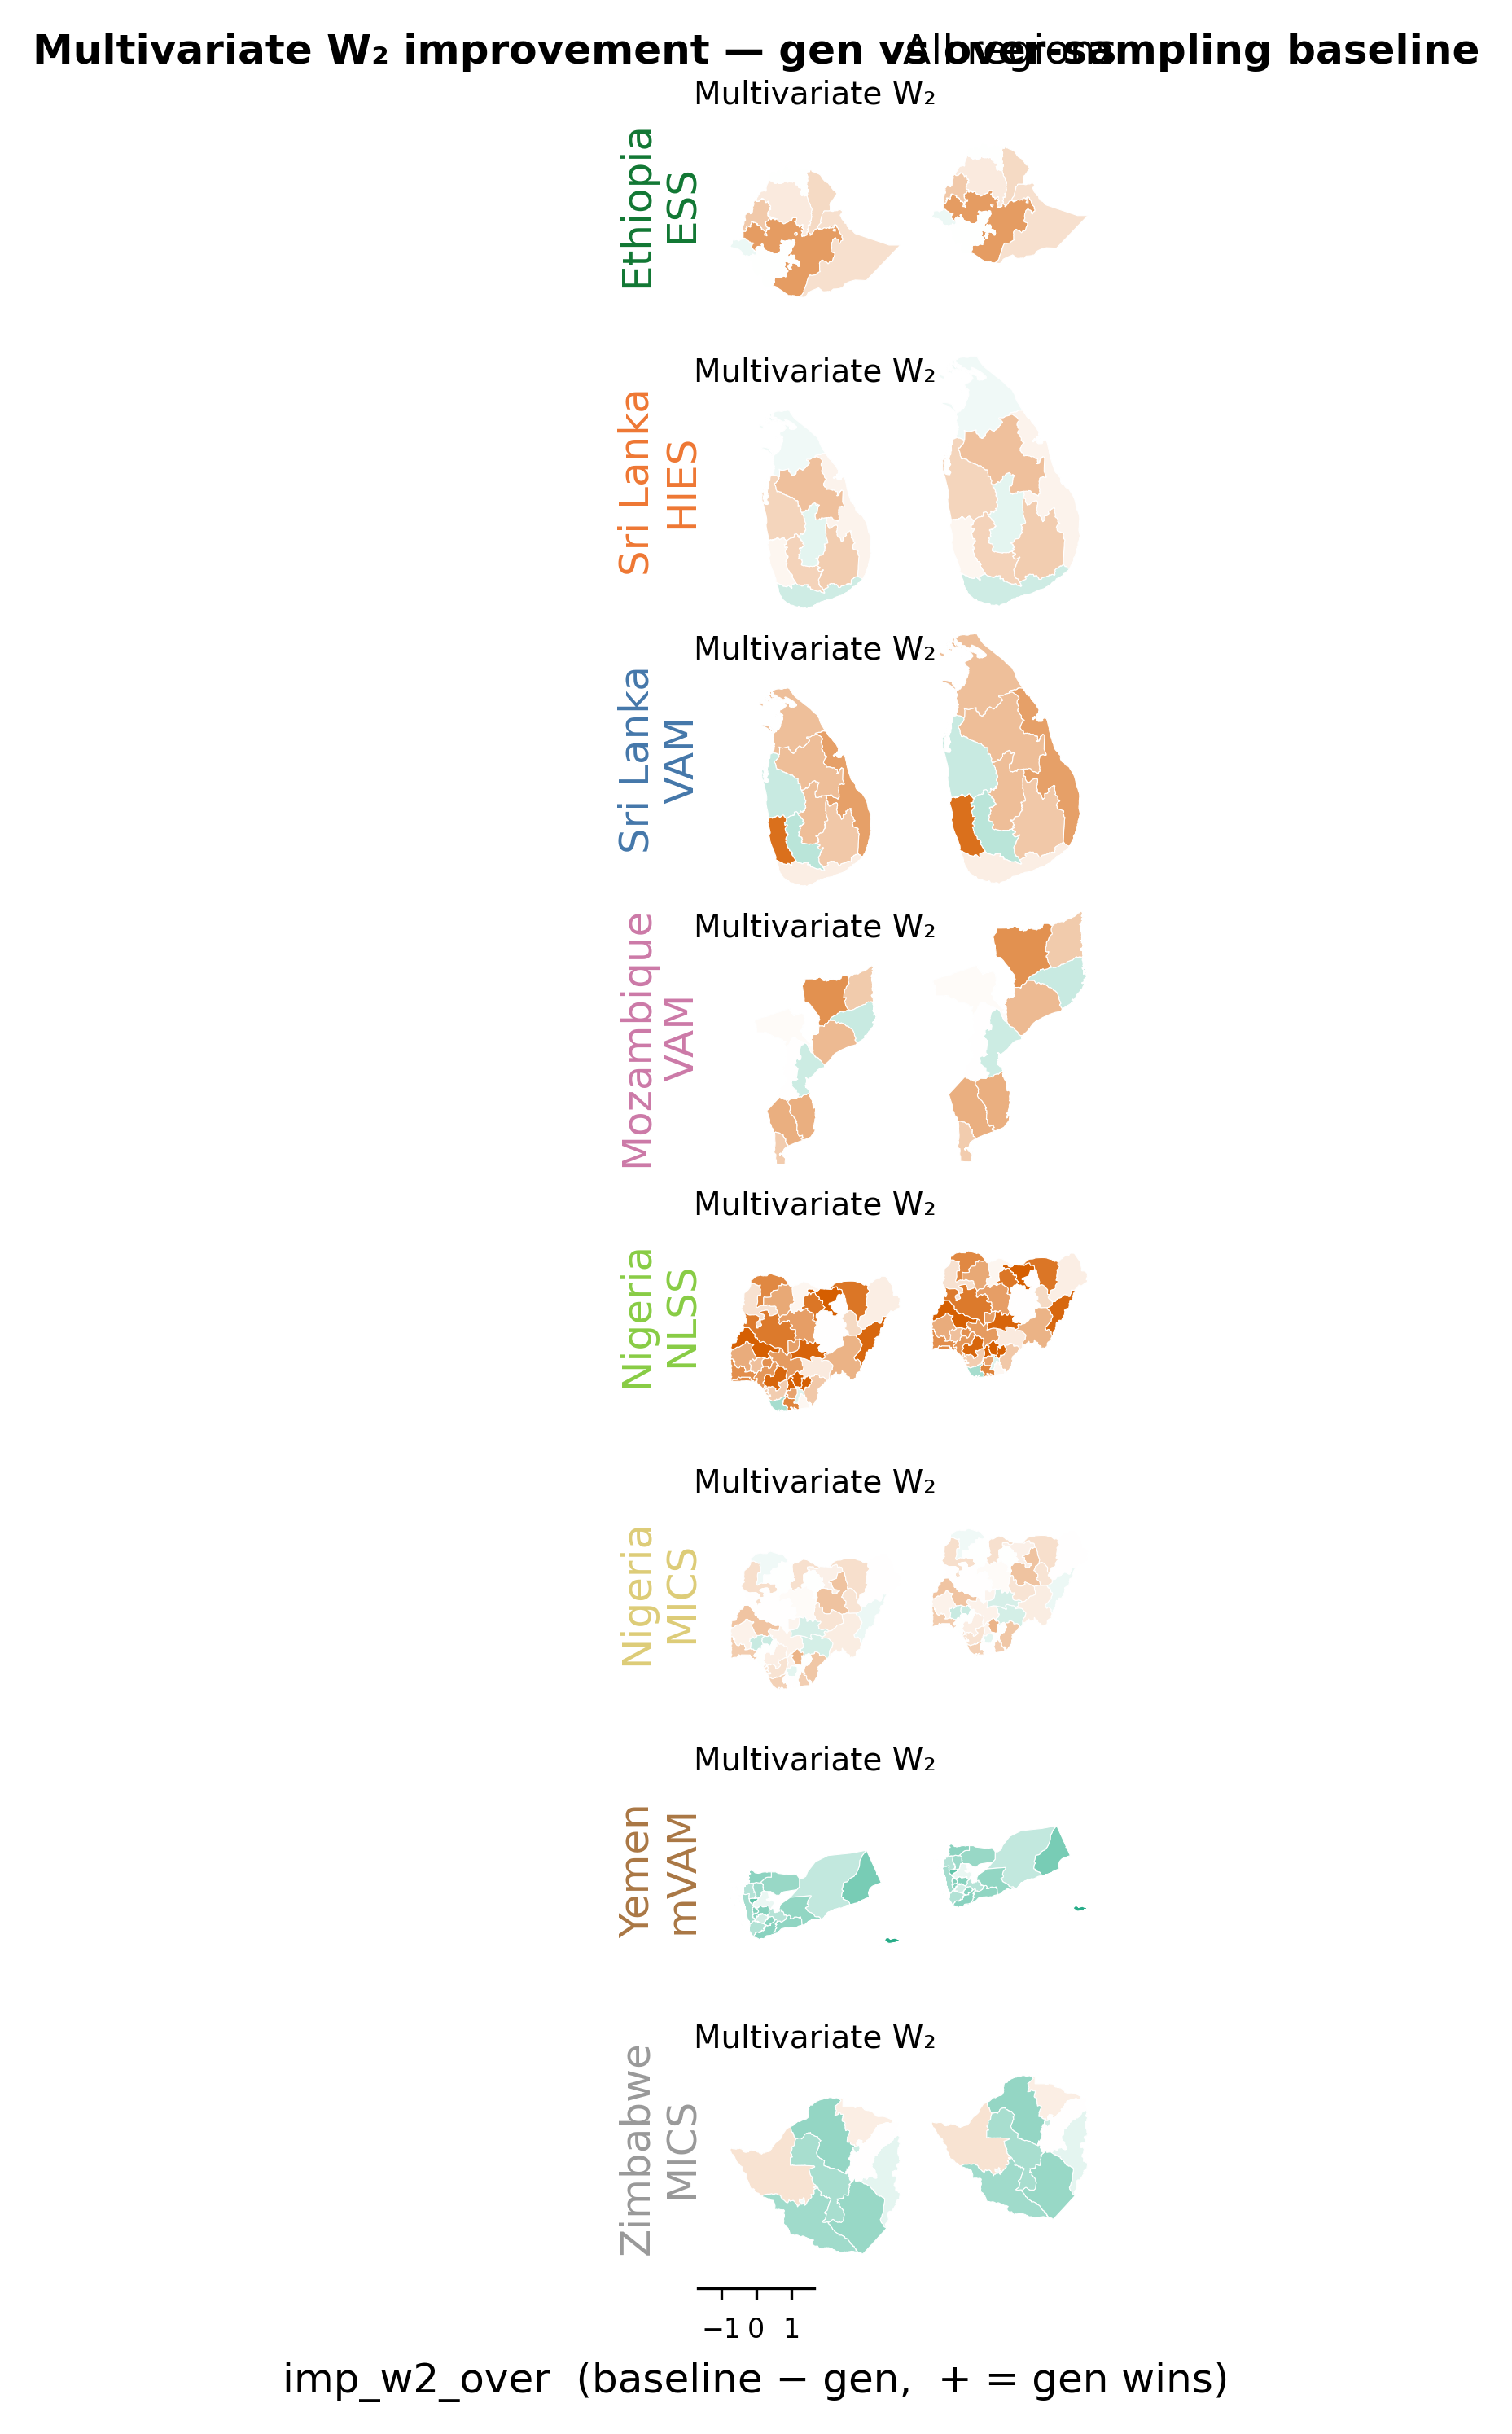

In [23]:
plot_w2_improvement(gdf_w2, "imp_w2_over", "Multivariate W₂ improvement — gen vs over-sampling baseline")

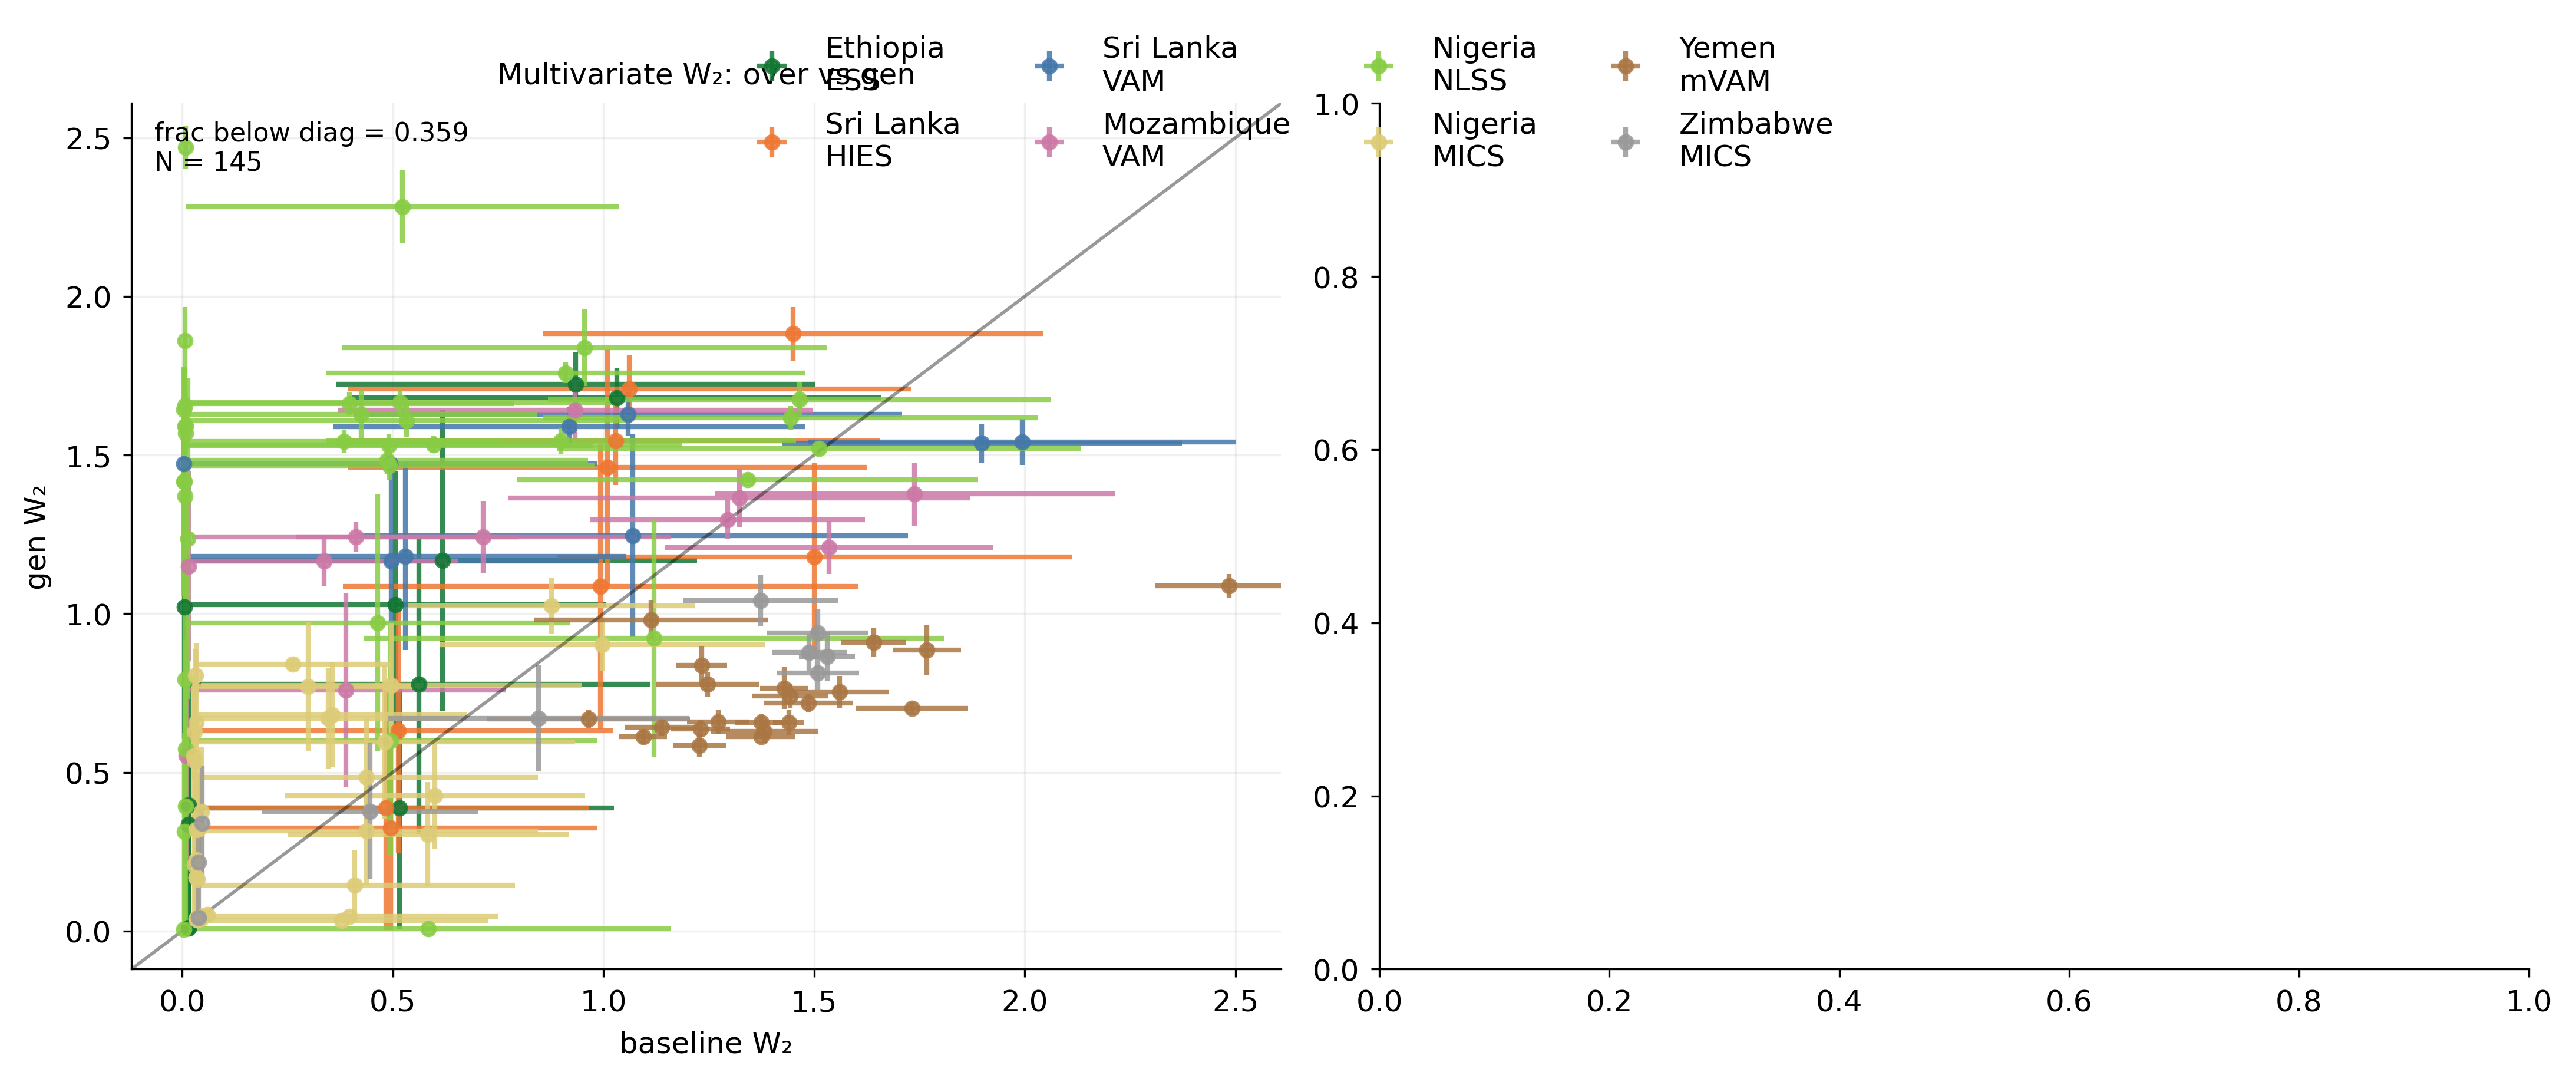

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

pairs = [
    ("w2_over_mean", "w2_over_se", "w2_gen_mean", "w2_gen_se",  "Multivariate W₂: over vs gen"),
]

for ax, (xmean, xse, ymean, yse, title) in zip(axes, pairs):
    for exp_id in exp_ids:
        d = w2_adm1[w2_adm1["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none", alpha=0.85, markersize=4,
            color=exp_color_map[exp_id], label=DISPLAY_LABELS.get(exp_id, exp_id),
        )

    x = w2_adm1[xmean].to_numpy()
    y = w2_adm1[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x):
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) or 0.1
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linewidth=1, color="k", alpha=0.4)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        frac = float(np.mean(y < x))
        ax.text(0.02, 0.98,
                f"frac below diag = {frac:.3f}\nN = {len(x)}",
                transform=ax.transAxes, va="top", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("baseline W₂")
    ax.set_ylabel("gen W₂")
    ax.grid(True, alpha=0.18, linewidth=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02),
           ncol=4, frameon=False)
fig.tight_layout()
plt.savefig(OUT_DIR / "w2_scatter.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()